In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path
from tqdm.auto import tqdm
from pd_estim_A.data.data_import import (
    load_data, load_ecb_1y_yield,
    fill_liabilities, drop_high_leverage_firms,
    prepare_merton_inputs, prepare_nig_inputs
)
from pd_estim_A.data.cds_df import get_cds_panel
from pd_estim_A.models.nig.nig_apath import (
    NIGParams,
    invert_assets_weekly_for_firm,
)

from pd_estim_A.models.nig.nig_em import (
    fit_nig_params_from_weekly_assets,
)

from pd_estim_A.models.nig.nig_pd import (
    pd_terminal_nig_weekly,
    pd_weekly_one_firm,
)

c:\Users\vkeenan\AppData\Local\miniconda3\envs\Accenture\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Paths
print(Path.cwd())
data_path = Path.cwd() / ".." / "data" / "raw"
output_path = Path.cwd() / ".." / "data" / "derived"

# Load data and prepare panels
ret_daily, bs, coverage = load_data(
    data_path / "Jan2025_Accenture_Dataset_ErasmusCase.xlsx",
    start_date="2012-01-01",
    end_date="2025-12-19",
    enforce_coverage=True,
    coverage_tol=0.995,
    liabilities_scale="auto",
    verbose=True,
)

df_rf = load_ecb_1y_yield(
    startPeriod="2010-01-01",
    endPeriod="2025-12-31",
    out_file= output_path / "ecb_yc_1y_aaa.xml",
    verify_ssl=True,  # recommended if it works
)

df_cal = ret_daily[["date"]].drop_duplicates().sort_values("date").reset_index(drop=True)

debt_daily = fill_liabilities(bs, df_cal)

ret_filt, bs_filt, lev_by_firm, dropped = drop_high_leverage_firms(
    ret_daily,
    bs,
    df_calendar=df_cal,
    debt_daily=debt_daily,
    lev_threshold=8.0,
    lev_agg="median",
    verbose=True,
)

# keep debt panel consistent with filtered firms
keep = set(ret_filt["gvkey"].astype(str).unique())
debt_daily_filt = debt_daily[debt_daily["gvkey"].astype(str).isin(keep)].copy()


nig_df, em_cache = prepare_nig_inputs(ret_filt, bs_filt, df_rf, debt_daily=debt_daily_filt, build_em=False)
print(nig_df.head())
print(nig_df.shape)
print(nig_df.describe())

c:\Users\vkeenan\OneDrive - Delft University of Technology\Documents\University\QRM\Accenture Project\code\notebooks_test
[load_data] Firms (ret_daily): 46
[load_data] Date range (ret_daily): 2012-01-03 .. 2025-12-19
[load_data] Coverage min/median/max: 0.999 / 1.000 / 1.000
[load_data] liabilities_scale_used: 1e+06
[load_data] QA mcap_reported<=0 rows (raw windowed mkt): 62
Data has been written to c:\Users\vkeenan\OneDrive - Delft University of Technology\Documents\University\QRM\Accenture Project\code\notebooks_test\..\data\derived\ecb_yc_1y_aaa.xml
[drop_high_leverage_firms] agg=median, threshold=8.0
[drop_high_leverage_firms] firms before: 46 | after: 36
[drop_high_leverage_firms] dropped firms: 10
    gvkey       date             E          isin  \
0  100022 2012-01-03  3.328431e+10  DE0005190003   
1  100080 2012-01-03  4.268705e+10  DE000BAY0017   
2  100312 2012-01-03  1.469717e+09  DE0007030009   
3  100581 2012-01-03  4.935351e+10  FR0000120321   
4  100957 2012-01-03  2.931

In [3]:
# call cds panel and merge
cds = get_cds_panel(
    project_root= Path.cwd() / "..",
    save_csv=False,
    verbose=True,
)
# ensure types
merton = nig_df.copy()
merton["gvkey"] = merton["gvkey"].astype(str)
merton["date"]  = pd.to_datetime(merton["date"])

cds["gvkey"] = cds["gvkey"].astype(str)
cds["date"]  = pd.to_datetime(cds["date"])

# keep only firms that exist in BOTH (drop firms with no CDS)
common_gv = sorted(set(merton["gvkey"].unique()) & set(cds["gvkey"].unique()))
merton = merton[merton["gvkey"].isin(common_gv)].copy()
cds = cds[cds["gvkey"].isin(common_gv)].copy()

# also drop CDS rows whose dates are outside merged's date range
dmin, dmax = merton["date"].min(), merton["date"].max()
cds = cds[(cds["date"] >= dmin) & (cds["date"] <= dmax)].copy()

# merge-asof onto merged's dates (direction='backward')
merton = merton.sort_values(["date", "gvkey"]).reset_index(drop=True)
cds    = cds.sort_values(["date", "gvkey"]).reset_index(drop=True)

merged_cds = pd.merge_asof(
    merton,
    cds,
    on="date",
    by="gvkey",
    direction="backward",
    allow_exact_matches=True,
)

# drop rows where CDS still missing
nig_df = merged_cds.dropna(subset=["cds"]).reset_index(drop=True)

print("firms after intersection:", nig_df["gvkey"].nunique())
print("rows after merge:", len(nig_df))
print("date range:", nig_df["date"].min(), "→", nig_df["date"].max())

[load_data] Firms (ret_daily): 46
[load_data] Date range (ret_daily): 2012-01-03 .. 2025-12-19
[load_data] Coverage min/median/max: 0.999 / 1.000 / 1.000
[load_data] liabilities_scale_used: 1e+06
[load_data] QA mcap_reported<=0 rows (raw windowed mkt): 62
[get_cds_panel] sheets read: 22 | rows parsed: 67015 | unmapped sheets: 0
firms after intersection: 21
rows after merge: 65569
date range: 2014-01-01 00:00:00 → 2025-12-19 00:00:00


In [4]:
# Cell 2 — rolling configuration

TRAIN_YEARS = 2
STEP_FREQ = "QE"
WEEK_ENDING = "W-FRI"

T_INV = 1.0                  # 1Y maturity used in inversion
HORIZON_WEEKS = 52.0         # 1Y PD horizon on weekly scale

DATA_END = pd.Timestamp("2024-12-31")   # keep equal to Merton if you want clean comparison
LAST_TRAIN_END = DATA_END - pd.offsets.QuarterEnd(1)

MIN_DAILY_ROWS = 10
MIN_WEEKLY_RETURNS = 60      # require enough weekly implied asset returns in each 2Y window

P0 = NIGParams(alpha=15.0, beta=-3.0, delta=0.20, mu=0.00)

INVERT_U = 120.0
INVERT_N = 2000

EM_MAX_ITER = 80
EM_TOL = 1e-6

MAX_FIRMS = None
MAX_WINDOWS = None

In [5]:
# Cell 3 — panel preparation
# Assumes nig_df already exists and has at least:
# gvkey, date, E, L, r
# plus optionally company, country_iso, etc.

panel = nig_df.copy()
panel["gvkey"] = panel["gvkey"].astype(str)
panel["date"] = pd.to_datetime(panel["date"])

needed_cols = ["gvkey", "date", "company", "E", "L", "r"]
panel = panel[[c for c in needed_cols if c in panel.columns]].copy()

for c in ["E", "L", "r"]:
    panel[c] = pd.to_numeric(panel[c], errors="coerce")

panel = (
    panel.dropna(subset=["gvkey", "date", "E", "L", "r"])
         .query("E > 0 and L > 0")
         .sort_values(["gvkey", "date"])
         .reset_index(drop=True)
)

firm_daily = {}
for gvkey, g in panel.groupby("gvkey", sort=False):
    g = g.sort_values("date").groupby("date", as_index=False).last()
    firm_daily[gvkey] = g.set_index("date")

gvkeys_all = sorted(firm_daily.keys())
if MAX_FIRMS is not None:
    gvkeys_all = gvkeys_all[:int(MAX_FIRMS)]

print("Firms loaded:", len(firm_daily), "| Firms in run:", len(gvkeys_all))
print("Panel date range:", panel["date"].min().date(), "to", panel["date"].max().date())
print("LAST_TRAIN_END:", LAST_TRAIN_END.date(), "| DATA_END:", DATA_END.date())
display(panel.head())

Firms loaded: 21 | Firms in run: 21
Panel date range: 2014-01-01 to 2025-12-19
LAST_TRAIN_END: 2024-09-30 | DATA_END: 2024-12-31


,gvkey,date,company,E,L,r
0,100022,2014-01-01,BAYERISCHE MOTOREN WERKE AKT,5.130203e+10,1.014480e+11,0.000942
1,100022,2014-01-02,BAYERISCHE MOTOREN WERKE AKT,5.029068e+10,1.014480e+11,0.001069
2,100022,2014-01-03,BAYERISCHE MOTOREN WERKE AKT,5.055556e+10,1.014480e+11,0.000991
3,100022,2014-01-06,BAYERISCHE MOTOREN WERKE AKT,4.995958e+10,1.014480e+11,0.001006
4,100022,2014-01-07,BAYERISCHE MOTOREN WERKE AKT,5.029670e+10,1.014480e+11,0.001057


In [6]:
# Cell 4 — build the rolling window schedule

global_min_date = panel["date"].min()
earliest_end = global_min_date + pd.DateOffset(years=TRAIN_YEARS) - pd.Timedelta(days=1)

train_ends = pd.date_range(start=earliest_end, end=LAST_TRAIN_END, freq=STEP_FREQ)
train_ends = pd.to_datetime(train_ends)

if MAX_WINDOWS is not None:
    train_ends = train_ends[:int(MAX_WINDOWS)]

windows = []
for train_end in train_ends:
    train_start = train_end - pd.DateOffset(years=TRAIN_YEARS) + pd.Timedelta(days=1)
    oos_start = train_end + pd.Timedelta(days=1)
    oos_end = train_end + pd.offsets.QuarterEnd(1)

    windows.append(
        {
            "train_start": pd.Timestamp(train_start),
            "train_end": pd.Timestamp(train_end),
            "oos_start": pd.Timestamp(oos_start),
            "oos_end": pd.Timestamp(oos_end),
        }
    )

windows_df = pd.DataFrame(windows)
display(windows_df.head())
display(windows_df.tail())
print("n_windows:", len(windows_df))

,train_start,train_end,oos_start,oos_end
0,2014-01-01,2015-12-31,2016-01-01,2016-03-31
1,2014-04-01,2016-03-31,2016-04-01,2016-06-30
2,2014-07-01,2016-06-30,2016-07-01,2016-09-30
3,2014-10-01,2016-09-30,2016-10-01,2016-12-31
4,2015-01-01,2016-12-31,2017-01-01,2017-03-31


,train_start,train_end,oos_start,oos_end
31,2021-10-01,2023-09-30,2023-10-01,2023-12-31
32,2022-01-01,2023-12-31,2024-01-01,2024-03-31
33,2022-04-01,2024-03-31,2024-04-01,2024-06-30
34,2022-07-01,2024-06-30,2024-07-01,2024-09-30
35,2022-10-01,2024-09-30,2024-10-01,2024-12-31


n_windows: 36


In [ ]:
# Cell 5 — thin helpers

def row_to_nig_params(row: pd.Series) -> NIGParams:
    return NIGParams(
        alpha=float(row["alpha"]),
        beta=float(row["beta"]),
        delta=float(row["delta"]),
        mu=float(row["mu"]),
    )


def fit_one_nig_window(
    assets_weekly: pd.DataFrame,
    p_start: NIGParams,
    *,
    em_max_iter: int = 80,
    em_tol: float = 1e-6,
    alpha_min: float = 1.75,
) -> tuple[NIGParams, pd.DataFrame]:
    """
    One EM fit on the full current training window, using the existing rolling fitter
    in single-window mode.
    """
    n_ret = int(assets_weekly["dlogA"].notna().sum())
    if n_ret < 10:
        raise ValueError(f"Too few weekly implied asset returns: {n_ret}")

    upd = fit_nig_params_from_weekly_assets(
        assets_weekly,
        p0=p_start,
        window_weeks=n_ret,
        refit_every=n_ret,
        em_max_iter=em_max_iter,
        em_tol=em_tol,
        alpha_min=alpha_min,
        use_theta=True,
        prefer_precomputed_theta=True,
        verbose=False,
    )

    if upd.empty:
        raise RuntimeError("Single-window NIG fit produced no update row.")

    return row_to_nig_params(upd.iloc[-1]), upd


def one_row_param_update(train_end: pd.Timestamp, p_hat: NIGParams) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "date": [pd.Timestamp(train_end)],
            "alpha": [float(p_hat.alpha)],
            "beta": [float(p_hat.beta)],
            "delta": [float(p_hat.delta)],
            "mu": [float(p_hat.mu)],
        }
    )


def nig_annual_to_weekly(p: NIGParams, weeks_per_year: float = 52.0) -> NIGParams:
    return NIGParams(
        alpha=float(p.alpha),
        beta=float(p.beta),
        delta=float(p.delta) / float(weeks_per_year),
        mu=float(p.mu) / float(weeks_per_year),
    )

In [ ]:
# Cell 6 — rolling one-pass NIG estimation

roll_summary_rows = []
roll_weekly_is_rows = []
roll_weekly_oos_rows = []

t0_all = time.time()

# warm start ONLY for EM
prev_p_em = {}

# stable pricing / inversion seed
P0_INV = NIGParams(alpha=10.0, beta=0.0, delta=0.20, mu=0.00)
P0_EM = nig_annual_to_weekly(P0_INV)

for w in tqdm(windows, desc="Rolling NIG windows"):
    train_start = w["train_start"]
    train_end   = w["train_end"]
    oos_start   = w["oos_start"]
    oos_end     = w["oos_end"]

    for gvkey in gvkeys_all:
        g_all = firm_daily.get(gvkey)
        if g_all is None or g_all.empty:
            roll_summary_rows.append(
                {
                    "gvkey": gvkey,
                    "train_start": train_start,
                    "train_end": train_end,
                    "oos_start": oos_start,
                    "oos_end": oos_end,
                    "ok": False,
                    "msg": "missing_firm_panel",
                }
            )
            continue

        # TRAINING SLICE
        g_train = g_all.loc[(g_all.index >= train_start) & (g_all.index <= train_end)].copy()
        if g_train.empty or len(g_train) < MIN_DAILY_ROWS:
            roll_summary_rows.append(
                {
                    "gvkey": gvkey,
                    "train_start": train_start,
                    "train_end": train_end,
                    "oos_start": oos_start,
                    "oos_end": oos_end,
                    "ok": False,
                    "msg": "too_few_daily_rows_train",
                    "n_daily_train": int(len(g_train)),
                }
            )
            continue

        g_train2 = g_train.reset_index().rename(columns={"index": "date"})
        g_train2 = (
            g_train2.dropna(subset=["date", "E", "L", "r"])
                    .query("E > 0 and L > 0")
                    .sort_values("date")
                    .reset_index(drop=True)
        )

        if len(g_train2) < MIN_DAILY_ROWS:
            roll_summary_rows.append(
                {
                    "gvkey": gvkey,
                    "train_start": train_start,
                    "train_end": train_end,
                    "oos_start": oos_start,
                    "oos_end": oos_end,
                    "ok": False,
                    "msg": "too_few_daily_rows_train_after_clean",
                    "n_daily_train": int(len(g_train2)),
                }
            )
            continue

        p_inv_seed = P0_INV
        p_em_seed = prev_p_em.get(gvkey, P0_EM)

        # ONE INVERSION PASS ON TRAIN WINDOW
        try:
            weekly_is = invert_assets_weekly_for_firm(
                g_train2,
                p_inv_seed,
                tau=T_INV,
                U=INVERT_U,
                n=INVERT_N,
                week_ending=WEEK_ENDING,
            )
        except Exception as e:
            roll_summary_rows.append(
                {
                    "gvkey": gvkey,
                    "train_start": train_start,
                    "train_end": train_end,
                    "oos_start": oos_start,
                    "oos_end": oos_end,
                    "ok": False,
                    "msg": f"fail_train_inversion:{type(e).__name__}:{str(e)[:180]}",
                    "n_daily_train": int(len(g_train2)),
                }
            )
            continue

        n_weekly_ret = int(weekly_is["dlogA"].notna().sum())
        if n_weekly_ret < MIN_WEEKLY_RETURNS:
            roll_summary_rows.append(
                {
                    "gvkey": gvkey,
                    "train_start": train_start,
                    "train_end": train_end,
                    "oos_start": oos_start,
                    "oos_end": oos_end,
                    "ok": False,
                    "msg": f"too_few_weekly_returns:{n_weekly_ret}",
                    "n_daily_train": int(len(g_train2)),
                    "n_weekly_train": int(len(weekly_is)),
                }
            )
            continue

        # ONE EM FIT ON TRAIN WINDOW
        try:
            p_hat_weekly, upd_one = fit_one_nig_window(
                weekly_is,
                p_em_seed,
                em_max_iter=EM_MAX_ITER,
                em_tol=EM_TOL,
                alpha_min=1.75,
            )
        except Exception as e:
            roll_summary_rows.append(
                {
                    "gvkey": gvkey,
                    "train_start": train_start,
                    "train_end": train_end,
                    "oos_start": oos_start,
                    "oos_end": oos_end,
                    "ok": False,
                    "msg": f"fail_train_em:{type(e).__name__}:{str(e)[:180]}",
                    "n_daily_train": int(len(g_train2)),
                    "n_weekly_train": int(len(weekly_is)),
                }
            )
            continue

        prev_p_em[gvkey] = p_hat_weekly

        # TRAIN-END PD
        last_is = weekly_is.sort_values("date").iloc[-1]
        pd_is = pd_terminal_nig_weekly(
            float(last_is["A_hat"]),
            float(last_is["L"]),
            p_hat_weekly,
            horizon_weeks=HORIZON_WEEKS,
        )

        roll_summary_rows.append(
            {
                "gvkey": gvkey,
                "train_start": train_start,
                "train_end": train_end,
                "oos_start": oos_start,
                "oos_end": oos_end,
                "ok": True,
                "msg": "ok",
                "alpha": float(p_hat_weekly.alpha),
                "beta": float(p_hat_weekly.beta),
                "delta": float(p_hat_weekly.delta),
                "mu": float(p_hat_weekly.mu),
                "emp_mean": float(upd_one.iloc[-1]["emp_mean"]),
                "mod_mean": float(upd_one.iloc[-1]["mod_mean"]),
                "emp_std": float(upd_one.iloc[-1]["emp_std"]),
                "mod_std": float(upd_one.iloc[-1]["mod_std"]),
                "alpha_required_from_theta": float(upd_one.iloc[-1]["alpha_required_from_theta"])
                    if np.isfinite(upd_one.iloc[-1]["alpha_required_from_theta"]) else np.nan,
                "alpha_hits_floor": bool(upd_one.iloc[-1]["alpha_hits_floor"]),
                "pd_date_is": pd.Timestamp(last_is["date"]),
                "A_used_is": float(last_is["A_hat"]),
                "L_used_is": float(last_is["L"]),
                "r_used_is": float(last_is["r"]),
                "PD_1y_is": float(pd_is),
                "n_daily_train": int(len(g_train2)),
                "n_weekly_train": int(len(weekly_is)),
                "n_weekly_returns_train": int(n_weekly_ret),
            }
        )

        weekly_is_store = weekly_is.copy()
        weekly_is_store["gvkey"] = gvkey
        weekly_is_store["train_end"] = train_end
        weekly_is_store["alpha"] = float(p_hat_weekly.alpha)
        weekly_is_store["beta"] = float(p_hat_weekly.beta)
        weekly_is_store["delta"] = float(p_hat_weekly.delta)
        weekly_is_store["mu"] = float(p_hat_weekly.mu)
        weekly_is_store["PD_1y_is"] = [
            pd_terminal_nig_weekly(a, l, p_hat_weekly, horizon_weeks=HORIZON_WEEKS)
            for a, l in zip(
                weekly_is_store["A_hat"].astype(float),
                weekly_is_store["L"].astype(float),
            )
        ]
        roll_weekly_is_rows.append(weekly_is_store)

        # OOS QUARTER
        g_oos = g_all.loc[(g_all.index >= oos_start) & (g_all.index <= oos_end)].copy()
        if g_oos.empty:
            continue

        g_oos2 = g_oos.reset_index().rename(columns={"index": "date"})
        g_oos2 = (
            g_oos2.dropna(subset=["date", "E", "L", "r"])
                  .query("E > 0 and L > 0")
                  .sort_values("date")
                  .reset_index(drop=True)
        )
        if g_oos2.empty:
            continue

        try:
            weekly_oos = invert_assets_weekly_for_firm(
                g_oos2,
                P0_INV,
                tau=T_INV,
                U=INVERT_U,
                n=INVERT_N,
                week_ending=WEEK_ENDING,
            )
        except Exception as e:
            roll_summary_rows.append(
                {
                    "gvkey": gvkey,
                    "train_start": train_start,
                    "train_end": train_end,
                    "oos_start": oos_start,
                    "oos_end": oos_end,
                    "ok": False,
                    "msg": f"fail_oos_inversion:{type(e).__name__}:{str(e)[:180]}",
                }
            )
            continue

        if weekly_oos.empty:
            continue

        upd_oos = one_row_param_update(train_end, p_hat_weekly)

        try:
            pd_oos = pd_weekly_one_firm(
                weekly_oos,
                gvkey=str(gvkey),
                param_updates=upd_oos,
                p0=p_hat_weekly,
                horizon_weeks=HORIZON_WEEKS,
            )
        except Exception as e:
            roll_summary_rows.append(
                {
                    "gvkey": gvkey,
                    "train_start": train_start,
                    "train_end": train_end,
                    "oos_start": oos_start,
                    "oos_end": oos_end,
                    "ok": False,
                    "msg": f"fail_oos_pd:{type(e).__name__}:{str(e)[:180]}",
                }
            )
            continue

        oos_df_this = weekly_oos.merge(
            pd_oos[["date", "PD_1y"]],
            on="date",
            how="left",
        ).rename(columns={"PD_1y": "PD_1y_oos"})

        oos_df_this["gvkey"] = gvkey
        oos_df_this["train_end"] = train_end
        oos_df_this["alpha"] = float(p_hat_weekly.alpha)
        oos_df_this["beta"] = float(p_hat_weekly.beta)
        oos_df_this["delta"] = float(p_hat_weekly.delta)
        oos_df_this["mu"] = float(p_hat_weekly.mu)

        roll_weekly_oos_rows.append(oos_df_this)

print("Total runtime (sec):", round(time.time() - t0_all, 2))

Rolling NIG windows: 100%|██████████| 36/36 [1:10:37<00:00, 117.72s/it]

Total runtime (sec): 4237.93


In [14]:
print("len(roll_summary_rows):", len(roll_summary_rows))
print("len(roll_weekly_is_rows):", len(roll_weekly_is_rows))
print("len(roll_weekly_oos_rows):", len(roll_weekly_oos_rows))

if len(roll_weekly_oos_rows):
    print("first OOS chunk columns:", roll_weekly_oos_rows[0].columns.tolist())
else:
    print("No OOS chunks were created.")

len(roll_summary_rows): 756
len(roll_weekly_is_rows): 756
len(roll_weekly_oos_rows): 756
first OOS chunk columns: ['date', 'E', 'L', 'r', 'A_hat', 'theta', 'logA', 'dlogA', 'PD_1y_oos', 'gvkey', 'train_end', 'alpha', 'beta', 'delta', 'mu']


In [15]:
# Cell 7 — assemble outputs

roll_summary_nig_df = (
    pd.DataFrame(roll_summary_rows)
      .sort_values(["train_end", "gvkey", "ok"], ascending=[True, True, False])
      .reset_index(drop=True)
)

roll_weekly_nig_is_df = (
    pd.concat(roll_weekly_is_rows, ignore_index=True)
      .sort_values(["train_end", "gvkey", "date"])
      .reset_index(drop=True)
) if len(roll_weekly_is_rows) else pd.DataFrame()

if len(roll_weekly_oos_rows):
    roll_weekly_nig_oos_df = (
        pd.concat(roll_weekly_oos_rows, ignore_index=True)
          .sort_values(["train_end", "gvkey", "date"])
          .reset_index(drop=True)
    )
else:
    roll_weekly_nig_oos_df = pd.DataFrame(
        columns=["gvkey", "date", "alpha", "beta", "delta", "mu", "A_hat", "L", "PD_1y_oos", "train_end"]
    )

print("roll_summary_nig_df shape:", roll_summary_nig_df.shape)
print("roll_weekly_nig_is_df shape:", roll_weekly_nig_is_df.shape)
print("roll_weekly_nig_oos_df shape:", roll_weekly_nig_oos_df.shape)

display(roll_summary_nig_df.head())
display(roll_weekly_nig_is_df.head())
display(roll_weekly_nig_oos_df.head())

roll_summary_nig_df shape: (756, 25)
roll_weekly_nig_is_df shape: (79296, 15)
roll_weekly_nig_oos_df shape: (10206, 15)


,gvkey,train_start,train_end,oos_start,oos_end,ok,msg,alpha,beta,delta,...,alpha_required_from_theta,alpha_hits_floor,pd_date_is,A_used_is,L_used_is,r_used_is,PD_1y_is,n_daily_train,n_weekly_train,n_weekly_returns_train
0,100022,2014-01-01,2015-12-31,2016-01-01,2016-03-31,True,ok,3.0,0.003605,0.000630,...,0.697206,True,2015-12-31,1.766054e+11,1.173660e+11,-0.003968,0.003788,522,105,104
1,100080,2014-01-01,2015-12-31,2016-01-01,2016-03-31,True,ok,3.0,0.000984,0.002556,...,0.699827,True,2015-12-31,1.459754e+11,5.001600e+10,-0.003968,0.000784,522,105,104
2,100957,2014-01-01,2015-12-31,2016-01-01,2016-03-31,True,ok,3.0,-0.006100,0.000379,...,0.706910,True,2015-12-31,9.971793e+10,5.798090e+10,-0.003968,0.001287,522,105,104
3,101202,2014-01-01,2015-12-31,2016-01-01,2016-03-31,True,ok,3.0,-0.001595,0.001095,...,0.702406,True,2015-12-31,5.062672e+10,1.489800e+10,-0.003968,0.000196,522,105,104
4,101204,2014-01-01,2015-12-31,2016-01-01,2016-03-31,True,ok,3.0,-0.001108,0.001884,...,0.701919,True,2015-12-31,1.439100e+11,4.112400e+10,-0.003968,0.000401,522,105,104


,date,E,L,r,A_hat,theta,logA,dlogA,gvkey,train_end,alpha,beta,delta,mu,PD_1y_is
0,2014-01-03,5.055556e+10,1.014480e+11,0.000991,1.519031e+11,-0.450513,25.746508,NaN,100022,2015-12-31,3.0,0.003605,0.00063,0.001448,0.003893
1,2014-01-10,5.005590e+10,1.014480e+11,0.000963,1.514063e+11,-0.451918,25.743233,-0.003276,100022,2015-12-31,3.0,0.003605,0.00063,0.001448,0.003965
2,2014-01-17,5.189801e+10,1.014480e+11,0.000996,1.532450e+11,-0.450268,25.755304,0.012071,100022,2015-12-31,3.0,0.003605,0.00063,0.001448,0.003707
3,2014-01-24,4.934555e+10,1.014480e+11,0.000794,1.507131e+11,-0.460365,25.738644,-0.016660,100022,2015-12-31,3.0,0.003605,0.00063,0.001448,0.004068
4,2014-01-31,4.865325e+10,1.014480e+11,0.000371,1.500636e+11,-0.481468,25.734325,-0.004318,100022,2015-12-31,3.0,0.003605,0.00063,0.001448,0.004168


,date,E,L,r,A_hat,theta,logA,dlogA,PD_1y_oos,gvkey,train_end,alpha,beta,delta,mu
0,2016-01-01,5.877279e+10,1.173660e+11,-0.003968,1.766054e+11,-0.698118,25.897184,NaN,0.003788,100022,2015-12-31,3.0,0.003605,0.00063,0.001448
1,2016-01-08,5.023048e+10,1.173660e+11,-0.004354,1.681087e+11,-0.717396,25.847876,-0.049308,0.005011,100022,2015-12-31,3.0,0.003605,0.00063,0.001448
2,2016-01-15,4.696767e+10,1.173660e+11,-0.004190,1.648265e+11,-0.709213,25.828159,-0.019717,0.005626,100022,2015-12-31,3.0,0.003605,0.00063,0.001448
3,2016-01-22,4.798504e+10,1.173660e+11,-0.004325,1.658598e+11,-0.715947,25.834409,0.006249,0.005422,100022,2015-12-31,3.0,0.003605,0.00063,0.001448
4,2016-01-29,4.614895e+10,1.173660e+11,-0.004508,1.640452e+11,-0.725059,25.823408,-0.011001,0.005787,100022,2015-12-31,3.0,0.003605,0.00063,0.001448


In [16]:

# Cell 8 — build final_nig_df analogous to your Merton final_df
is_last = (
    roll_weekly_nig_is_df.sort_values(["gvkey", "train_end", "date"])
    .groupby(["gvkey", "train_end"], as_index=False)
    .tail(1)
    [["gvkey", "train_end", "date", "A_hat", "L", "PD_1y_is", "alpha", "beta", "delta", "mu"]]
    .rename(columns={"A_hat": "A_used", "L": "L_used", "PD_1y_is": "PD_1y"})
)

train_end_rows = pd.DataFrame(
    {
        "gvkey": is_last["gvkey"].astype(str),
        "date": pd.to_datetime(is_last["date"]),
        "alpha": is_last["alpha"].astype(float),
        "beta": is_last["beta"].astype(float),
        "delta": is_last["delta"].astype(float),
        "mu": is_last["mu"].astype(float),
        "A_used": is_last["A_used"].astype(float),
        "L_used": is_last["L_used"].astype(float),
        "PD_1y": is_last["PD_1y"].astype(float),
        "train_end_date": pd.to_datetime(is_last["train_end"]),
        "training_end": 1,
    }
)

oos_rows = pd.DataFrame(
    {
        "gvkey": roll_weekly_nig_oos_df["gvkey"].astype(str),
        "date": pd.to_datetime(roll_weekly_nig_oos_df["date"]),
        "alpha": roll_weekly_nig_oos_df["alpha"].astype(float),
        "beta": roll_weekly_nig_oos_df["beta"].astype(float),
        "delta": roll_weekly_nig_oos_df["delta"].astype(float),
        "mu": roll_weekly_nig_oos_df["mu"].astype(float),
        "A_used": roll_weekly_nig_oos_df["A_hat"].astype(float),
        "L_used": roll_weekly_nig_oos_df["L"].astype(float),
        "PD_1y": roll_weekly_nig_oos_df["PD_1y_oos"].astype(float),
        "train_end_date": pd.to_datetime(roll_weekly_nig_oos_df["train_end"]),
        "training_end": 0,
    }
)

final_nig_df = pd.concat([train_end_rows, oos_rows], ignore_index=True)

final_nig_df = (
    final_nig_df.sort_values(["gvkey", "date", "training_end"], ascending=[True, True, False])
                .drop_duplicates(subset=["gvkey", "date"], keep="first")
                .sort_values(["gvkey", "date"])
                .reset_index(drop=True)
)

final_nig_df["training_end"] = final_nig_df["training_end"].astype(int)

final_nig_df = final_nig_df[
    ["gvkey", "date", "alpha", "beta", "delta", "mu", "A_used", "L_used", "PD_1y", "train_end_date", "training_end"]
]

display(final_nig_df.head(20))
print(final_nig_df.shape)


,gvkey,date,alpha,beta,delta,mu,A_used,L_used,PD_1y,train_end_date,training_end
0,100022,2015-12-31,3.0,0.003605,0.000630,0.001448,1.766054e+11,1.173660e+11,0.003788,2015-12-31,1
1,100022,2016-01-01,3.0,0.003605,0.000630,0.001448,1.766054e+11,1.173660e+11,0.003788,2015-12-31,0
2,100022,2016-01-08,3.0,0.003605,0.000630,0.001448,1.681087e+11,1.173660e+11,0.005011,2015-12-31,0
3,100022,2016-01-15,3.0,0.003605,0.000630,0.001448,1.648265e+11,1.173660e+11,0.005626,2015-12-31,0
4,100022,2016-01-22,3.0,0.003605,0.000630,0.001448,1.658598e+11,1.173660e+11,0.005422,2015-12-31,0
5,100022,2016-01-29,3.0,0.003605,0.000630,0.001448,1.640452e+11,1.173660e+11,0.005787,2015-12-31,0
6,100022,2016-02-05,3.0,0.003605,0.000630,0.001448,1.614967e+11,1.173660e+11,0.006359,2015-12-31,0
7,100022,2016-02-12,3.0,0.003605,0.000630,0.001448,1.602333e+11,1.173660e+11,0.006670,2015-12-31,0
8,100022,2016-02-19,3.0,0.003605,0.000630,0.001448,1.623882e+11,1.173660e+11,0.006150,2015-12-31,0
9,100022,2016-02-26,3.0,0.003605,0.000630,0.001448,1.624404e+11,1.173660e+11,0.006138,2015-12-31,0


(10227, 11)


In [17]:
# Cell 9 — quick diagnostics

if not roll_summary_nig_df.empty:
    print("Unique train_end windows:", roll_summary_nig_df["train_end"].nunique())
    print("Share ok:", roll_summary_nig_df["ok"].mean())
    print(roll_summary_nig_df.loc[roll_summary_nig_df["ok"] == True, ["alpha", "beta", "delta", "mu"]].describe())

    g0 = roll_summary_nig_df.loc[roll_summary_nig_df["ok"] == True, "gvkey"].astype(str).unique()
    if len(g0):
        example = g0[0]
        display(
            roll_summary_nig_df[
                (roll_summary_nig_df["gvkey"] == example) & (roll_summary_nig_df["ok"] == True)
            ][
                ["gvkey", "train_end", "alpha", "beta", "delta", "mu", "PD_1y_is", "emp_std", "mod_std"]
            ].head(15)
        )

if not roll_weekly_nig_oos_df.empty and len(g0):
    display(
        roll_weekly_nig_oos_df[
            roll_weekly_nig_oos_df["gvkey"] == example
        ][
            ["gvkey", "train_end", "date", "alpha", "beta", "delta", "mu", "A_hat", "PD_1y_oos"]
        ].head(30)
    )
# Cell 10 — optional: inspect failures only

fail_view = roll_summary_nig_df.loc[roll_summary_nig_df["ok"] == False].copy()
display(fail_view.head(30))
print(fail_view["msg"].value_counts().head(20))

Unique train_end windows: 36
Share ok: 1.0
       alpha        beta       delta          mu
count  756.0  756.000000  756.000000  756.000000
mean     3.0   -0.000003    0.001592    0.001045
std      0.0    0.000456    0.001321    0.001892
min      3.0   -0.006100    0.000147   -0.006618
25%      3.0   -0.000096    0.000688   -0.000066
50%      3.0   -0.000009    0.001305    0.000913
75%      3.0    0.000102    0.001914    0.001974
max      3.0    0.003605    0.007526    0.008374


,gvkey,train_end,alpha,beta,delta,mu,PD_1y_is,emp_std,mod_std
0,100022,2015-12-31,3.0,0.003605,0.000630,1.448045e-03,0.003788,0.014490,0.014490
21,100022,2016-03-31,3.0,0.000135,0.000877,1.112948e-03,0.010004,0.017099,0.017099
42,100022,2016-06-30,3.0,0.000206,0.000895,5.734191e-04,0.017001,0.017276,0.017276
63,100022,2016-09-30,3.0,0.000180,0.000872,1.262668e-03,0.010610,0.017052,0.017052
84,100022,2016-12-31,3.0,0.000192,0.000868,1.594782e-03,0.007160,0.017013,0.017013
105,100022,2017-03-31,3.0,0.000254,0.000803,3.455173e-04,0.012135,0.016364,0.016364
126,100022,2017-06-30,3.0,0.000158,0.000741,7.212115e-04,0.010704,0.015714,0.015714
147,100022,2017-09-30,3.0,0.000175,0.000677,1.564327e-03,0.006717,0.015022,0.015022
168,100022,2017-12-31,3.0,0.000286,0.000620,9.274056e-04,0.007339,0.014372,0.014372
189,100022,2018-03-31,3.0,0.000618,0.000324,8.310967e-04,0.003611,0.010394,0.010394


,gvkey,train_end,date,alpha,beta,delta,mu,A_hat,PD_1y_oos
0,100022,2015-12-31,2016-01-01,3.0,0.003605,0.000630,0.001448,1.766054e+11,0.003788
1,100022,2015-12-31,2016-01-08,3.0,0.003605,0.000630,0.001448,1.681087e+11,0.005011
2,100022,2015-12-31,2016-01-15,3.0,0.003605,0.000630,0.001448,1.648265e+11,0.005626
3,100022,2015-12-31,2016-01-22,3.0,0.003605,0.000630,0.001448,1.658598e+11,0.005422
4,100022,2015-12-31,2016-01-29,3.0,0.003605,0.000630,0.001448,1.640452e+11,0.005787
5,100022,2015-12-31,2016-02-05,3.0,0.003605,0.000630,0.001448,1.614967e+11,0.006359
6,100022,2015-12-31,2016-02-12,3.0,0.003605,0.000630,0.001448,1.602333e+11,0.006670
7,100022,2015-12-31,2016-02-19,3.0,0.003605,0.000630,0.001448,1.623882e+11,0.006150
8,100022,2015-12-31,2016-02-26,3.0,0.003605,0.000630,0.001448,1.624404e+11,0.006138
9,100022,2015-12-31,2016-03-04,3.0,0.003605,0.000630,0.001448,1.677078e+11,0.005081


,gvkey,train_start,train_end,oos_start,oos_end,ok,msg,alpha,beta,delta,...,alpha_required_from_theta,alpha_hits_floor,pd_date_is,A_used_is,L_used_is,r_used_is,PD_1y_is,n_daily_train,n_weekly_train,n_weekly_returns_train


Series([], Name: count, dtype: int64)


In [19]:
# save final_df as CSV in the current working directory
output_path = Path.cwd() / ".." / "data" / "derived"
final_nig_df.to_csv(output_path / "NIG_weekly_rolling.csv", index=False)

### Sanity Checks

In [20]:
# Check 1 — how constrained is the NIG fit?

ok = roll_summary_nig_df.loc[roll_summary_nig_df["ok"] == True].copy()

print("share alpha == 3.0:", np.mean(np.isclose(ok["alpha"], 3.0)))
print("share alpha_hits_floor:", ok["alpha_hits_floor"].mean())

print(
    ok[["alpha", "alpha_required_from_theta"]]
    .assign(gap=lambda x: x["alpha"] - x["alpha_required_from_theta"])
    .describe()
)

display(
    ok.loc[:, ["gvkey", "train_end", "alpha", "alpha_required_from_theta", "alpha_hits_floor"]]
      .head(20)
)

share alpha == 3.0: 1.0
share alpha_hits_floor: 1.0
       alpha  alpha_required_from_theta         gap
count  756.0                 756.000000  756.000000
mean     3.0                   1.205645    1.794355
std      0.0                   0.526899    0.526899
min      3.0                   0.697206    0.738606
25%      3.0                   0.936862    1.959770
50%      3.0                   0.940498    2.059502
75%      3.0                   1.040230    2.063138
max      3.0                   2.261394    2.302794


,gvkey,train_end,alpha,alpha_required_from_theta,alpha_hits_floor
0,100022,2015-12-31,3.0,0.697206,True
1,100080,2015-12-31,3.0,0.699827,True
2,100957,2015-12-31,3.0,0.706910,True
3,101202,2015-12-31,3.0,0.702406,True
4,101204,2015-12-31,3.0,0.701919,True
5,101336,2015-12-31,3.0,0.700815,True
6,101361,2015-12-31,3.0,0.702387,True
7,102296,2015-12-31,3.0,0.703329,True
8,14447,2015-12-31,3.0,0.700439,True
9,17436,2015-12-31,3.0,0.700822,True


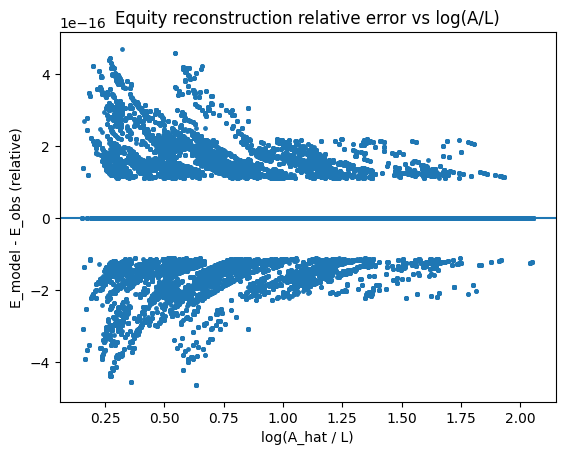

count    7.929600e+04
mean     8.160652e-17
std      9.688540e-17
min      0.000000e+00
50%      0.000000e+00
90%      2.057115e-16
95%      2.458869e-16
99%      3.568072e-16
99.9%    4.211620e-16
max      4.708307e-16
Name: E_rel_err, dtype: float64
share |rel_err| > 5e-4: 0.0
count    7.923000e+03
mean     1.701578e-16
std      1.146301e-16
min      0.000000e+00
50%      1.603025e-16
90%      3.341390e-16
95%      3.732843e-16
99%      4.169311e-16
max      4.708307e-16
Name: E_rel_err, dtype: float64


,gvkey,date,E,E_model,E_rel_err,A_hat,L,log_lev
1369,220940,2014-01-31,2.430617e+10,2.430617e+10,4.708307e-16,8.787858e+10,6.359600e+10,0.323405
48127,23667,2021-03-05,2.475530e+10,2.475530e+10,-4.622885e-16,5.320542e+10,2.826000e+10,0.632713
50319,23667,2021-03-05,2.475530e+10,2.475530e+10,-4.622885e-16,5.320542e+10,2.826000e+10,0.632713
52511,23667,2021-03-05,2.475530e+10,2.475530e+10,-4.622885e-16,5.320542e+10,2.826000e+10,0.632713
54703,23667,2021-03-05,2.475530e+10,2.475530e+10,-4.622885e-16,5.320542e+10,2.826000e+10,0.632713
56895,23667,2021-03-05,2.475530e+10,2.475530e+10,-4.622885e-16,5.320542e+10,2.826000e+10,0.632713
59087,23667,2021-03-05,2.475530e+10,2.475530e+10,-4.622885e-16,5.320542e+10,2.826000e+10,0.632713
61279,23667,2021-03-05,2.475530e+10,2.475530e+10,-4.622885e-16,5.320542e+10,2.826000e+10,0.632713
63471,23667,2021-03-05,2.475530e+10,2.475530e+10,-4.622885e-16,5.320542e+10,2.826000e+10,0.632713
72368,23667,2023-12-29,2.499398e+10,2.499398e+10,4.578739e-16,5.714964e+10,3.315000e+10,0.544630


In [21]:
# Check 2 — equity reconstruction errors

from pd_estim_A.models.nig.nig_safety import check_equity_reconstruction_errors

assets_weekly_all = roll_weekly_nig_is_df.copy()
assets_weekly_all["gvkey"] = assets_weekly_all["gvkey"].astype(str)
assets_weekly_all["date"] = pd.to_datetime(assets_weekly_all["date"])

eq = check_equity_reconstruction_errors(
    assets_weekly_all,
    tau_inv=1.0,
    use_theta_col="theta",
    max_abs_rel_err_warn=5e-4,
    plot=True,
)

print(eq["summary_abs_rel_error"])
print("share |rel_err| > 5e-4:", eq["share_abs_rel_err_gt_thresh"])
print(eq["summary_abs_rel_error_high_leverage_tail"])
display(eq["worst_rows"])

In [22]:
# Check 3 — outliers in implied weekly asset returns

from pd_estim_A.models.nig.nig_safety import check_asset_return_outliers

tails = check_asset_return_outliers(
    roll_weekly_nig_is_df,
    ret_col="dlogA",
    z_thresh=10.0,
    topk=10,
)

display(tails["summary"].sort_values(["share_|z|>thr", "top1pct_energy_share"], ascending=False).head(15))
display(tails["worst_firms"])

bad_gv = tails["worst_firms"].iloc[0]["gvkey"]
bad_examples = [r for r in tails["per_firm"] if r["gvkey"] == bad_gv][0]["examples_top_outliers"]
display(bad_examples)

,gvkey,n,share_|z|>thr,max_|ret|,top1pct_energy_share
17,23667,3740,0.006417,0.320364,0.612504
12,201794,3740,0.004813,0.202976,0.589112
15,221616,3740,0.004278,0.297748,0.676827
18,23671,3740,0.004278,0.304641,0.466332
20,61616,3740,0.004278,0.169264,0.420600
1,100080,3740,0.002139,0.377363,0.523165
0,100022,3740,0.002139,0.106333,0.398246
3,101202,3740,0.002139,0.174538,0.289370
10,17452,3740,0.002139,0.164799,0.287261
19,241456,3740,0.002139,0.197854,0.269544


,gvkey,n,share_|z|>thr,max_|ret|,top1pct_energy_share
17,23667,3740,0.006417,0.320364,0.612504
12,201794,3740,0.004813,0.202976,0.589112
15,221616,3740,0.004278,0.297748,0.676827
18,23671,3740,0.004278,0.304641,0.466332
20,61616,3740,0.004278,0.169264,0.420600
1,100080,3740,0.002139,0.377363,0.523165
0,100022,3740,0.002139,0.106333,0.398246
3,101202,3740,0.002139,0.174538,0.289370
10,17452,3740,0.002139,0.164799,0.287261
19,241456,3740,0.002139,0.197854,0.269544


,date,dlogA,robust_z,abs_ret
15071,2016-07-29,0.320364,23.831392,0.320364
17263,2016-07-29,0.320364,23.831392,0.320364
23839,2016-07-29,0.320364,23.831392,0.320364
12879,2016-07-29,0.320364,23.831392,0.320364
19455,2016-07-29,0.320364,23.831392,0.320364
21647,2016-07-29,0.320364,23.831392,0.320364
10687,2016-07-29,0.320364,23.831392,0.320364
8495,2016-07-29,0.320364,23.831392,0.320364
15103,2017-03-10,0.239686,17.794677,0.239686
17295,2017-03-10,0.239686,17.794677,0.239686


In [23]:
# Check 4 — are quarterly refits causing artificial PD discontinuities?

from pd_estim_A.models.nig.nig_safety import check_refit_date_jumps

# Build parameter update panel from successful train-end rows
updates_all = (
    roll_summary_nig_df.loc[roll_summary_nig_df["ok"] == True, ["gvkey", "train_end", "alpha", "beta", "delta", "mu"]]
    .rename(columns={"train_end": "date"})
    .copy()
)

# Build weekly PD panel
pds_weekly_all = (
    roll_weekly_nig_oos_df.loc[:, ["gvkey", "date", "PD_1y_oos"]]
    .rename(columns={"PD_1y_oos": "PD_1y"})
    .copy()
)

jumps = check_refit_date_jumps(
    pds_weekly_all,
    updates_all,
    pd_col="PD_1y",
    refit_merge_tol_days=7,
)

print("median refit/non-refit abs logit jump ratio:", jumps["ratio_median_refit_to_nonrefit"])
print("refit jump summary:\n", jumps["abs_dlogit_pd_refit_desc"])
print("non-refit jump summary:\n", jumps["abs_dlogit_pd_nonrefit_desc"])
display(jumps["top_abs_jumps"])

median refit/non-refit abs logit jump ratio: 1.2343753457931133
refit jump summary:
 count    1932.000000
mean        0.125901
std         0.184113
min         0.000000
50%         0.060215
90%         0.306794
95%         0.484091
99%         0.879209
max         2.213663
Name: dlogit_pd, dtype: float64
non-refit jump summary:
 count    364728.000000
mean          0.078810
std           0.112864
min           0.000000
50%           0.048782
90%           0.168266
95%           0.243321
99%           0.551210
max           2.213663
Name: dlogit_pd, dtype: float64


,gvkey,date,PD_1y,pd_prev,dlogit_pd,is_refit_week,refit_date,refit_dist_days
317340,23671,2017-03-31,0.017514,0.001945,2.213663,False,2015-12-31,456
317341,23671,2017-03-31,0.017514,0.001945,2.213663,False,2016-03-31,365
317342,23671,2017-03-31,0.017514,0.001945,2.213663,False,2016-06-30,274
317343,23671,2017-03-31,0.017514,0.001945,2.213663,False,2016-09-30,182
317344,23671,2017-03-31,0.017514,0.001945,2.213663,False,2016-12-31,90
317345,23671,2017-03-31,0.017514,0.001945,2.213663,True,2017-03-31,0
317346,23671,2017-03-31,0.017514,0.001945,2.213663,False,2017-06-30,91
317347,23671,2017-03-31,0.017514,0.001945,2.213663,False,2017-09-30,183
317348,23671,2017-03-31,0.017514,0.001945,2.213663,False,2017-12-31,275
317349,23671,2017-03-31,0.017514,0.001945,2.213663,False,2018-03-31,365


In [24]:
# Check 5 — economic monotonicity: higher leverage buffer -> lower PD

oos_chk = roll_weekly_nig_oos_df.copy()
oos_chk["log_A_over_L"] = np.log(oos_chk["A_hat"] / oos_chk["L"])

print(
    oos_chk[["log_A_over_L", "PD_1y_oos"]]
    .corr(method="spearman")
)

display(
    oos_chk[["gvkey", "date", "A_hat", "L", "log_A_over_L", "PD_1y_oos"]]
    .sort_values("PD_1y_oos", ascending=False)
    .head(20)
)

              log_A_over_L  PD_1y_oos
log_A_over_L      1.000000  -0.857244
PD_1y_oos        -0.857244   1.000000


,gvkey,date,A_hat,L,log_A_over_L,PD_1y_oos
9369,100080,2024-06-21,1.061984e+11,8.318100e+10,0.244291,0.105010
9360,100080,2024-04-19,1.063424e+11,8.318100e+10,0.245645,0.103015
9370,100080,2024-06-28,1.065588e+11,8.318100e+10,0.247678,0.100123
9359,100080,2024-04-12,1.070059e+11,8.318100e+10,0.251865,0.094530
9368,100080,2024-06-14,1.072249e+11,8.318100e+10,0.253910,0.091963
9361,100080,2024-04-26,1.073896e+11,8.318100e+10,0.255445,0.090102
9358,100080,2024-04-05,1.074519e+11,8.318100e+10,0.256024,0.089414
9365,100080,2024-05-24,1.075857e+11,8.318100e+10,0.257269,0.087961
5660,61616,2020-10-30,9.795548e+10,7.554000e+10,0.259851,0.087584
9362,100080,2024-05-03,1.080312e+11,8.318100e+10,0.261401,0.083377


### Alpha Sensitivity Tests

In [26]:
# Alpha-min sensitivity test on a small subset

ALPHA_GRID = [1.25, 1.75, 2.5, 3.0]
TEST_MAX_FIRMS = 5
TEST_MAX_WINDOWS = 8

test_gvkeys = gvkeys_all[:TEST_MAX_FIRMS]
test_windows = windows[:TEST_MAX_WINDOWS]

alpha_sens_summary = []
alpha_sens_pd_panels = {}

for alpha_min_test in ALPHA_GRID:
    print(f"\n=== alpha_min = {alpha_min_test} ===")

    roll_summary_rows_test = []
    roll_weekly_oos_rows_test = []
    prev_p_em_test = {}

    t0 = time.time()

    for w in test_windows:
        train_start = w["train_start"]
        train_end   = w["train_end"]
        oos_start   = w["oos_start"]
        oos_end     = w["oos_end"]

        for gvkey in test_gvkeys:
            g_all = firm_daily.get(gvkey)
            if g_all is None or g_all.empty:
                continue

            g_train = g_all.loc[(g_all.index >= train_start) & (g_all.index <= train_end)].copy()
            g_train2 = g_train.reset_index().rename(columns={"index": "date"})
            g_train2 = (
                g_train2.dropna(subset=["date", "E", "L", "r"])
                        .query("E > 0 and L > 0")
                        .sort_values("date")
                        .reset_index(drop=True)
            )
            if len(g_train2) < MIN_DAILY_ROWS:
                continue

            p_inv_seed = P0_INV
            p_em_seed = prev_p_em_test.get(gvkey, P0_EM)

            try:
                weekly_is = invert_assets_weekly_for_firm(
                    g_train2,
                    p_inv_seed,
                    tau=T_INV,
                    U=INVERT_U,
                    n=INVERT_N,
                    week_ending=WEEK_ENDING,
                )
            except Exception:
                continue

            n_weekly_ret = int(weekly_is["dlogA"].notna().sum())
            if n_weekly_ret < MIN_WEEKLY_RETURNS:
                continue

            try:
                p_hat_weekly, upd_one = fit_one_nig_window(
                    weekly_is,
                    p_em_seed,
                    em_max_iter=EM_MAX_ITER,
                    em_tol=EM_TOL,
                    alpha_min=alpha_min_test,
                )
            except Exception:
                continue

            prev_p_em_test[gvkey] = p_hat_weekly

            last_is = weekly_is.sort_values("date").iloc[-1]
            pd_is = pd_terminal_nig_weekly(
                float(last_is["A_hat"]),
                float(last_is["L"]),
                p_hat_weekly,
                horizon_weeks=HORIZON_WEEKS,
            )

            roll_summary_rows_test.append(
                {
                    "gvkey": gvkey,
                    "train_end": train_end,
                    "alpha_min_test": alpha_min_test,
                    "alpha": float(p_hat_weekly.alpha),
                    "beta": float(p_hat_weekly.beta),
                    "delta": float(p_hat_weekly.delta),
                    "mu": float(p_hat_weekly.mu),
                    "alpha_required_from_theta": float(upd_one.iloc[-1]["alpha_required_from_theta"])
                        if np.isfinite(upd_one.iloc[-1]["alpha_required_from_theta"]) else np.nan,
                    "alpha_hits_floor": bool(upd_one.iloc[-1]["alpha_hits_floor"]),
                    "PD_1y_is": float(pd_is),
                }
            )

            # OOS
            g_oos = g_all.loc[(g_all.index >= oos_start) & (g_all.index <= oos_end)].copy()
            g_oos2 = g_oos.reset_index().rename(columns={"index": "date"})
            g_oos2 = (
                g_oos2.dropna(subset=["date", "E", "L", "r"])
                      .query("E > 0 and L > 0")
                      .sort_values("date")
                      .reset_index(drop=True)
            )
            if g_oos2.empty:
                continue

            try:
                weekly_oos = invert_assets_weekly_for_firm(
                    g_oos2,
                    P0_INV,
                    tau=T_INV,
                    U=INVERT_U,
                    n=INVERT_N,
                    week_ending=WEEK_ENDING,
                )
            except Exception:
                continue

            upd_oos = one_row_param_update(train_end, p_hat_weekly)

            try:
                pd_oos = pd_weekly_one_firm(
                    weekly_oos,
                    gvkey=str(gvkey),
                    param_updates=upd_oos,
                    p0=p_hat_weekly,
                    horizon_weeks=HORIZON_WEEKS,
                )
            except Exception:
                continue

            oos_df_this = pd_oos[["gvkey", "date", "PD_1y"]].copy()
            oos_df_this["alpha_min_test"] = alpha_min_test
            roll_weekly_oos_rows_test.append(oos_df_this)

    summary_df = pd.DataFrame(roll_summary_rows_test)
    alpha_sens_summary.append(summary_df)

    if len(roll_weekly_oos_rows_test):
        alpha_sens_pd_panels[alpha_min_test] = pd.concat(roll_weekly_oos_rows_test, ignore_index=True)
    else:
        alpha_sens_pd_panels[alpha_min_test] = pd.DataFrame(columns=["gvkey", "date", "PD_1y", "alpha_min_test"])

    print("runtime sec:", round(time.time() - t0, 2))
    if not summary_df.empty:
        print("n successful train windows:", len(summary_df))
        print("share alpha at floor:", np.mean(np.isclose(summary_df["alpha"], alpha_min_test)))
        print("share alpha_hits_floor:", summary_df["alpha_hits_floor"].mean())
        print(summary_df[["alpha", "beta", "delta", "mu", "PD_1y_is"]].describe())


=== alpha_min = 1.25 ===
runtime sec: 226.74
n successful train windows: 40
share alpha at floor: 0.925
share alpha_hits_floor: 0.925
           alpha       beta      delta         mu   PD_1y_is
count  40.000000  40.000000  40.000000  40.000000  40.000000
mean    1.300893  -0.000093   0.000591   0.000759   0.003396
std     0.195383   0.001183   0.000314   0.000967   0.002732
min     1.250000  -0.006100   0.000159  -0.001571   0.000659
25%     1.250000  -0.000012   0.000328   0.000125   0.001661
50%     1.250000   0.000019   0.000585   0.000941   0.002333
75%     1.250000   0.000027   0.000847   0.001277   0.003720
max     2.258739   0.003605   0.001138   0.003128   0.012403

=== alpha_min = 1.75 ===
runtime sec: 175.78
n successful train windows: 40
share alpha at floor: 0.95
share alpha_hits_floor: 0.95
           alpha       beta      delta         mu   PD_1y_is
count  40.000000  40.000000  40.000000  40.000000  40.000000
mean    1.766909  -0.000083   0.000816   0.000759   0.003333


In [27]:
alpha_sens_summary_df = pd.concat(alpha_sens_summary, ignore_index=True)

display(
    alpha_sens_summary_df.groupby("alpha_min_test").agg(
        n_train_success=("gvkey", "size"),
        share_alpha_eq_floor=("alpha", lambda s: np.mean(np.isclose(s, s.name if False else s.iloc[0]*0 + s.iloc[0]))),  # ignore, use next table below
    )
)

display(
    alpha_sens_summary_df.groupby("alpha_min_test").apply(
        lambda g: pd.Series({
            "n_train_success": len(g),
            "share_alpha_eq_floor": np.mean(np.isclose(g["alpha"], g["alpha_min_test"])),
            "share_alpha_hits_floor": g["alpha_hits_floor"].mean(),
            "alpha_mean": g["alpha"].mean(),
            "alpha_std": g["alpha"].std(),
            "pd_is_mean": g["PD_1y_is"].mean(),
            "pd_is_std": g["PD_1y_is"].std(),
        })
    ).reset_index(drop=True)
)

,n_train_success,share_alpha_eq_floor
alpha_min_test,,
1.25,40,0.025
1.75,40,0.025
2.50,40,1.000
3.00,40,1.000


C:\Users\vkeenan\AppData\Local\Temp\ipykernel_21028\3123742775.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  alpha_sens_summary_df.groupby("alpha_min_test").apply(


,n_train_success,share_alpha_eq_floor,share_alpha_hits_floor,alpha_mean,alpha_std,pd_is_mean,pd_is_std
0,40.0,0.925,0.925,1.300893,0.195383,0.003396,0.002732
1,40.0,0.950,0.950,1.766909,0.084044,0.003333,0.003318
2,40.0,1.000,1.000,2.500000,0.000000,0.003030,0.003811
3,40.0,1.000,1.000,3.000000,0.000000,0.002801,0.003952
